# E_S4 — Filter cases by configurable MIC ranges

Split the complete E SNR-sweep dataset into three non-overlapping MIC ranges. Edit the first code cell to change the thresholds.

In [1]:
# ============================================================
# INPUT / OUTPUT PATHS — EDIT THESE VALUES FIRST
# Paths may be repository-relative or absolute.
# ============================================================
INPUT_DATA_DIR = 'E/output/S3_snr_mic_sweep'
SCATTER_POINTS_INPUT = 'E/output/S3_snr_mic_sweep/scatter_points.npz'
OUTPUT_DATA_DIR = 'E/output/S4_mic_range_filter'
CASES_FILENAME = 'cases.csv'
METRICS_FILENAME = 'metrics_full.parquet'

# ============================================================
# MIC THRESHOLDS
# Boundaries are: high [HIGH, MAX], middle [MID, HIGH), low [MIN, MID)
# ============================================================
MIC_MIN = 0.0
MIC_MID_MIN = 0.6
MIC_HIGH_MIN = 0.8
MIC_MAX = 1.0
SIMPLE_COMPLEX_CORRELATION_THRESHOLD = 0.7
STRONG_MONOTONICITY_SPEARMAN_THRESHOLD = 0.9

# Optional filters. Use None to keep every value.
INCLUDE_NULL = True
SELECTED_FAMILIES = None       # Example: ['F01', 'F03']
SELECTED_VARIANTS = None       # Example: ['strong']; None keeps all variants
VARIANT_LEVELS_TO_SPLIT = ['strong', 'standard', 'mild']
PLOT_VARIANTS = ['strong', 'standard', 'mild']
PLOT_REPEATS = None            # None uses all repeats; example: [1, 2, 3, 4, 5]

# Output controls.
SAVE_FULL_PARQUET = True
SAVE_MANIFEST_CSV = True
SAVE_VARIANT_SPLITS = True
SAVE_SIMPLE_COMPLEX_RESULTS = True
SAVE_STRONG_MONOTONICITY_RESULTS = True
SAVE_MIC_RANGE_FIGURES = True
FIGURE_DPI = 180
OVERWRITE = True

## Load and validate the E SNR-sweep data

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


def locate_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'E').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing E/.')


def resolve_configured_path(value: str) -> Path:
    path = Path(value).expanduser()
    return path.resolve() if path.is_absolute() else (REPO_ROOT / path).resolve()


REPO_ROOT = locate_repo_root()
DATA_DIR = resolve_configured_path(INPUT_DATA_DIR)
SCATTER_POINTS_PATH = resolve_configured_path(SCATTER_POINTS_INPUT)
OUTPUT_DIR = resolve_configured_path(OUTPUT_DATA_DIR)
CASES_PATH = DATA_DIR / CASES_FILENAME
METRICS_PATH = DATA_DIR / METRICS_FILENAME

if not CASES_PATH.exists():
    raise FileNotFoundError(CASES_PATH)
if not METRICS_PATH.exists():
    raise FileNotFoundError(METRICS_PATH)
if not SCATTER_POINTS_PATH.exists():
    raise FileNotFoundError(SCATTER_POINTS_PATH)

print(f'Cases:   {CASES_PATH}')
print(f'Metrics: {METRICS_PATH}')
print(f'Points:  {SCATTER_POINTS_PATH}')
print(f'Output:  {OUTPUT_DIR}')

Cases:   /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/E/output/S3_snr_mic_sweep/cases.csv
Metrics: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/E/output/S3_snr_mic_sweep/metrics_full.parquet
Points:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/E/output/S3_snr_mic_sweep/scatter_points.npz
Output:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/E/output/S4_mic_range_filter


In [3]:
if not (MIC_MIN < MIC_MID_MIN < MIC_HIGH_MIN < MIC_MAX):
    raise ValueError(
        'Thresholds must satisfy MIC_MIN < MIC_MID_MIN < '
        'MIC_HIGH_MIN < MIC_MAX.'
    )

cases = pd.read_csv(CASES_PATH)
metrics = pd.read_parquet(METRICS_PATH)

required_case_columns = {'case_id', 'family_id', 'variant_level', 'is_null'}
required_metric_columns = {'case_id', 'MIC'}
missing_case_columns = required_case_columns.difference(cases.columns)
missing_metric_columns = required_metric_columns.difference(metrics.columns)
if missing_case_columns:
    raise KeyError(f'Missing case columns: {sorted(missing_case_columns)}')
if missing_metric_columns:
    raise KeyError(f'Missing metric columns: {sorted(missing_metric_columns)}')
if cases['case_id'].duplicated().any():
    raise ValueError('cases.csv contains duplicate case_id values.')
if metrics['case_id'].duplicated().any():
    raise ValueError('metrics_full.parquet contains duplicate case_id values.')
if set(cases['case_id']) != set(metrics['case_id']):
    raise ValueError('Case IDs differ between the case and metric tables.')

data = cases.merge(metrics, on='case_id', how='inner', validate='one_to_one')

if not INCLUDE_NULL:
    data = data.loc[~data['is_null']].copy()
if SELECTED_FAMILIES is not None:
    data = data.loc[data['family_id'].isin(SELECTED_FAMILIES)].copy()
if SELECTED_VARIANTS is not None:
    data = data.loc[data['variant_level'].isin(SELECTED_VARIANTS)].copy()

available_variants = set(data.loc[~data['is_null'], 'variant_level'].dropna().unique())
missing_split_variants = set(VARIANT_LEVELS_TO_SPLIT).difference(available_variants)
if missing_split_variants:
    raise ValueError(f'Variant levels not found in the filtered data: {sorted(missing_split_variants)}')

mic = pd.to_numeric(data['MIC'], errors='raise')
epsilon = 1e-12
outside_domain = ~mic.between(MIC_MIN - epsilon, MIC_MAX + epsilon)
if outside_domain.any():
    sample = data.loc[outside_domain, ['case_id', 'MIC']].head()
    raise ValueError(
        f'{outside_domain.sum()} MIC values are outside [{MIC_MIN}, {MIC_MAX}].\n'
        f'{sample.to_string(index=False)}'
    )

# Clip only the tiny floating-point overshoot around 0 and 1 for bin assignment.
data['_MIC_for_filter'] = mic.clip(MIC_MIN, MIC_MAX)
print(f'Loaded {len(data):,} filtered-input cases × {len(data.columns) - 1} columns.')

Loaded 95,440 filtered-input cases × 96 columns.


## Apply the three non-overlapping MIC ranges

In [4]:
range_specs = [
    {
        'key': 'high',
        'label': f'[{MIC_HIGH_MIN:g}, {MIC_MAX:g}]',
        'lower': MIC_HIGH_MIN,
        'upper': MIC_MAX,
        'include_upper': True,
    },
    {
        'key': 'middle',
        'label': f'[{MIC_MID_MIN:g}, {MIC_HIGH_MIN:g})',
        'lower': MIC_MID_MIN,
        'upper': MIC_HIGH_MIN,
        'include_upper': False,
    },
    {
        'key': 'low',
        'label': f'[{MIC_MIN:g}, {MIC_MID_MIN:g})',
        'lower': MIC_MIN,
        'upper': MIC_MID_MIN,
        'include_upper': False,
    },
]

selections = {}
for spec in range_specs:
    values = data['_MIC_for_filter']
    upper_mask = values.le(spec['upper']) if spec['include_upper'] else values.lt(spec['upper'])
    mask = values.ge(spec['lower']) & upper_mask
    selected = data.loc[mask].drop(columns='_MIC_for_filter').copy()
    selected.insert(1, 'mic_range', spec['label'])
    selections[spec['key']] = selected

selected_ids = pd.concat(
    [frame[['case_id']] for frame in selections.values()],
    ignore_index=True,
)
if selected_ids['case_id'].duplicated().any():
    raise AssertionError('MIC ranges overlap; a case was selected more than once.')
if len(selected_ids) != len(data):
    raise AssertionError('MIC ranges do not cover every filtered-input case.')

summary_rows = []
for spec in range_specs:
    selected = selections[spec['key']]
    summary_rows.append({
        'range_key': spec['key'],
        'mic_range': spec['label'],
        'lower_bound': spec['lower'],
        'upper_bound': spec['upper'],
        'upper_bound_inclusive': spec['include_upper'],
        'n_cases': len(selected),
        'share_of_filtered_input': len(selected) / len(data) if len(data) else np.nan,
        'n_signal': int((~selected['is_null']).sum()),
        'n_null': int(selected['is_null'].sum()),
        'n_families': int(selected.loc[~selected['is_null'], 'family_id'].nunique()),
        'observed_MIC_min': selected['MIC'].min() if len(selected) else np.nan,
        'observed_MIC_max': selected['MIC'].max() if len(selected) else np.nan,
    })

summary = pd.DataFrame(summary_rows)
summary

,range_key,mic_range,lower_bound,upper_bound,upper_bound_inclusive,n_cases,share_of_filtered_input,n_signal,n_null,n_families,observed_MIC_min,observed_MIC_max
0,high,"[0.8, 1]",0.8,1.0,True,24643,0.258204,24643,0,12,0.800039,1.000000
1,middle,"[0.6, 0.8)",0.6,0.8,False,9567,0.100241,9567,0,14,0.600067,0.799957
2,low,"[0, 0.6)",0.0,0.6,False,61230,0.641555,61130,100,14,0.128446,0.599953


## Save filtered datasets, manifests, and summaries

In [5]:
def number_token(value: float) -> str:
    return f'{value:g}'.replace('-', 'm').replace('.', 'p')


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

manifest_columns = [
    'case_id', 'mic_range', 'trajectory_id', 'family_id', 'family_name',
    'variant_name', 'variant_level', 'repeat', 'nominal_snr', 'actual_snr',
    'inverse_snr', 'snr_zone', 'is_null', 'n_points', 'MIC', 'MCN', 'MEV',
    'distance_correlation',
]
manifest_columns = [column for column in manifest_columns if column in next(iter(selections.values())).columns]

saved_paths = []
variant_summary_rows = []
for spec in range_specs:
    selected = selections[spec['key']]
    stem = f"mic_{number_token(spec['lower'])}_to_{number_token(spec['upper'])}"

    if SAVE_FULL_PARQUET:
        parquet_path = OUTPUT_DIR / f'{stem}_full.parquet'
        if parquet_path.exists() and not OVERWRITE:
            raise FileExistsError(parquet_path)
        selected.to_parquet(parquet_path, index=False)
        saved_paths.append(parquet_path)

    if SAVE_MANIFEST_CSV:
        manifest_path = OUTPUT_DIR / f'{stem}_manifest.csv'
        if manifest_path.exists() and not OVERWRITE:
            raise FileExistsError(manifest_path)
        manifest = selected.loc[:, manifest_columns].copy()
        if 'distance_correlation' in manifest.columns:
            manifest = manifest.rename(columns={'distance_correlation': 'dCor'})
        manifest.to_csv(manifest_path, index=False)
        saved_paths.append(manifest_path)

    for variant_level in VARIANT_LEVELS_TO_SPLIT:
        variant_selected = selected.loc[selected['variant_level'].eq(variant_level)].copy()
        variant_summary_rows.append({
            'range_key': spec['key'],
            'mic_range': spec['label'],
            'variant_level': variant_level,
            'n_cases': len(variant_selected),
            'n_families': int(variant_selected['family_id'].nunique()),
            'observed_MIC_min': variant_selected['MIC'].min() if len(variant_selected) else np.nan,
            'observed_MIC_max': variant_selected['MIC'].max() if len(variant_selected) else np.nan,
        })

        if SAVE_VARIANT_SPLITS:
            variant_dir = OUTPUT_DIR / 'by_variant' / variant_level
            variant_dir.mkdir(parents=True, exist_ok=True)

            if SAVE_FULL_PARQUET:
                variant_parquet_path = variant_dir / f'{stem}_full.parquet'
                if variant_parquet_path.exists() and not OVERWRITE:
                    raise FileExistsError(variant_parquet_path)
                variant_selected.to_parquet(variant_parquet_path, index=False)
                saved_paths.append(variant_parquet_path)

            if SAVE_MANIFEST_CSV:
                variant_manifest_path = variant_dir / f'{stem}_manifest.csv'
                if variant_manifest_path.exists() and not OVERWRITE:
                    raise FileExistsError(variant_manifest_path)
                variant_manifest = variant_selected.loc[:, manifest_columns].copy()
                if 'distance_correlation' in variant_manifest.columns:
                    variant_manifest = variant_manifest.rename(columns={'distance_correlation': 'dCor'})
                variant_manifest.to_csv(variant_manifest_path, index=False)
                saved_paths.append(variant_manifest_path)

summary_path = OUTPUT_DIR / 'mic_range_summary.csv'
summary.to_csv(summary_path, index=False)
saved_paths.append(summary_path)

variant_summary = pd.DataFrame(variant_summary_rows)
variant_summary_path = OUTPUT_DIR / 'mic_range_summary_by_variant.csv'
variant_summary.to_csv(variant_summary_path, index=False)
saved_paths.append(variant_summary_path)

family_summary = pd.concat(
    [
        selected.groupby(['mic_range', 'family_id', 'family_name', 'variant_level'], dropna=False)
        .agg(n_cases=('case_id', 'size'), MIC_min=('MIC', 'min'), MIC_max=('MIC', 'max'))
        .reset_index()
        for selected in selections.values()
    ],
    ignore_index=True,
)
family_summary_path = OUTPUT_DIR / 'mic_range_counts_by_family.csv'
family_summary.to_csv(family_summary_path, index=False)
saved_paths.append(family_summary_path)

config = {
    'input_data_dir_config': INPUT_DATA_DIR,
    'scatter_points_input_config': SCATTER_POINTS_INPUT,
    'output_data_dir_config': OUTPUT_DATA_DIR,
    'resolved_input_data_dir': str(DATA_DIR),
    'resolved_scatter_points_path': str(SCATTER_POINTS_PATH),
    'resolved_output_data_dir': str(OUTPUT_DIR),
    'source_cases': str(CASES_PATH),
    'source_metrics': str(METRICS_PATH),
    'MIC_MIN': MIC_MIN,
    'MIC_MID_MIN': MIC_MID_MIN,
    'MIC_HIGH_MIN': MIC_HIGH_MIN,
    'MIC_MAX': MIC_MAX,
    'simple_complex_correlation_threshold': SIMPLE_COMPLEX_CORRELATION_THRESHOLD,
    'strong_monotonicity_spearman_threshold': STRONG_MONOTONICITY_SPEARMAN_THRESHOLD,
    'simple_complex_input_MIC_min': MIC_HIGH_MIN,
    'boundary_definition': {
        'high': f'[{MIC_HIGH_MIN:g}, {MIC_MAX:g}]',
        'middle': f'[{MIC_MID_MIN:g}, {MIC_HIGH_MIN:g})',
        'low': f'[{MIC_MIN:g}, {MIC_MID_MIN:g})',
    },
    'include_null': INCLUDE_NULL,
    'selected_families': SELECTED_FAMILIES,
    'selected_variants': SELECTED_VARIANTS,
    'variant_levels_to_split': VARIANT_LEVELS_TO_SPLIT,
    'save_variant_splits': SAVE_VARIANT_SPLITS,
    'save_strong_monotonicity_results': SAVE_STRONG_MONOTONICITY_RESULTS,
    'plot_variants': PLOT_VARIANTS,
    'plot_repeats': PLOT_REPEATS,
    'save_mic_range_figures': SAVE_MIC_RANGE_FIGURES,
    'figure_dpi': FIGURE_DPI,
    'n_filtered_input_cases': len(data),
}
config_path = OUTPUT_DIR / 'filter_config.json'
config_path.write_text(json.dumps(config, indent=2), encoding='utf-8')
saved_paths.append(config_path)

print(summary.to_string(index=False))
print('\nBy variant:')
print(variant_summary.to_string(index=False))
print('\nSaved:')
for path in saved_paths:
    print(f'  {path.relative_to(REPO_ROOT)}')

range_key  mic_range  lower_bound  upper_bound  upper_bound_inclusive  n_cases  share_of_filtered_input  n_signal  n_null  n_families  observed_MIC_min  observed_MIC_max
     high   [0.8, 1]          0.8          1.0                   True    24643                 0.258204     24643       0          12          0.800039          1.000000
   middle [0.6, 0.8)          0.6          0.8                  False     9567                 0.100241      9567       0          14          0.600067          0.799957
      low   [0, 0.6)          0.0          0.6                  False    61230                 0.641555     61130     100          14          0.128446          0.599953

By variant:
range_key  mic_range variant_level  n_cases  n_families  observed_MIC_min  observed_MIC_max
     high   [0.8, 1]        strong     7457          12          0.800236          1.000000
     high   [0.8, 1]      standard     8480          12          0.800039          1.000000
     high   [0.8, 1]          m

## MIC profiles with the configured range segments

The shaded horizontal bands use the same thresholds as the filtering step. Curves are repeat means for each relationship family.

Saved MIC range figures:
  E/output/S4_mic_range_filter/figures/mic_ranges_strong.png
  E/output/S4_mic_range_filter/figures/mic_ranges_standard.png
  E/output/S4_mic_range_filter/figures/mic_ranges_mild.png
  E/output/S4_mic_range_filter/figures/mic_ranges_all_variants_1x3.png

Strong only:


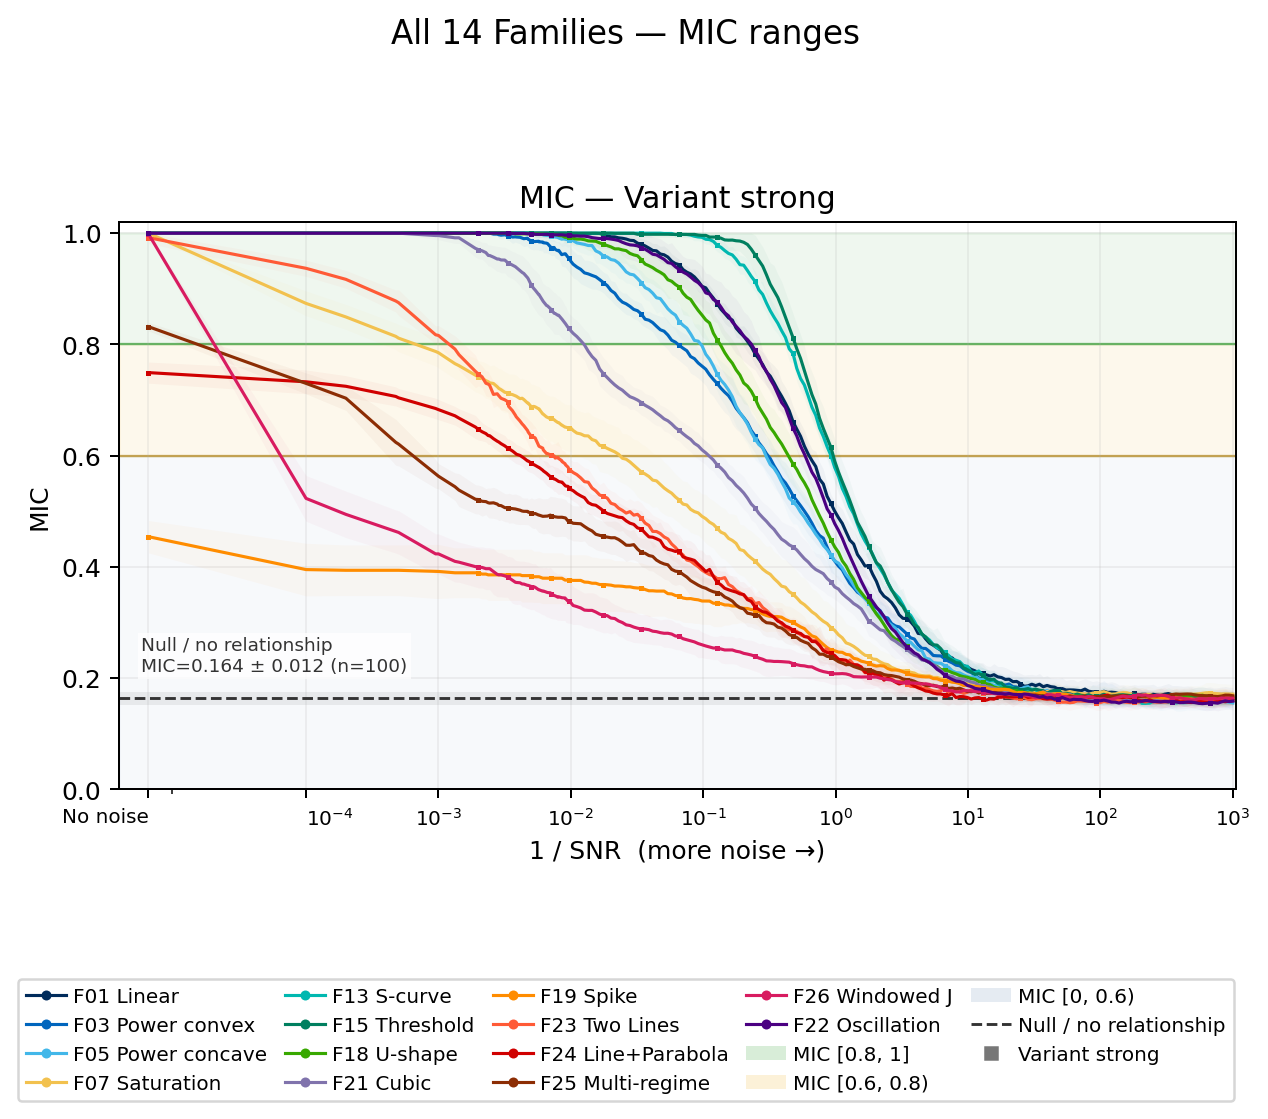


All variants:


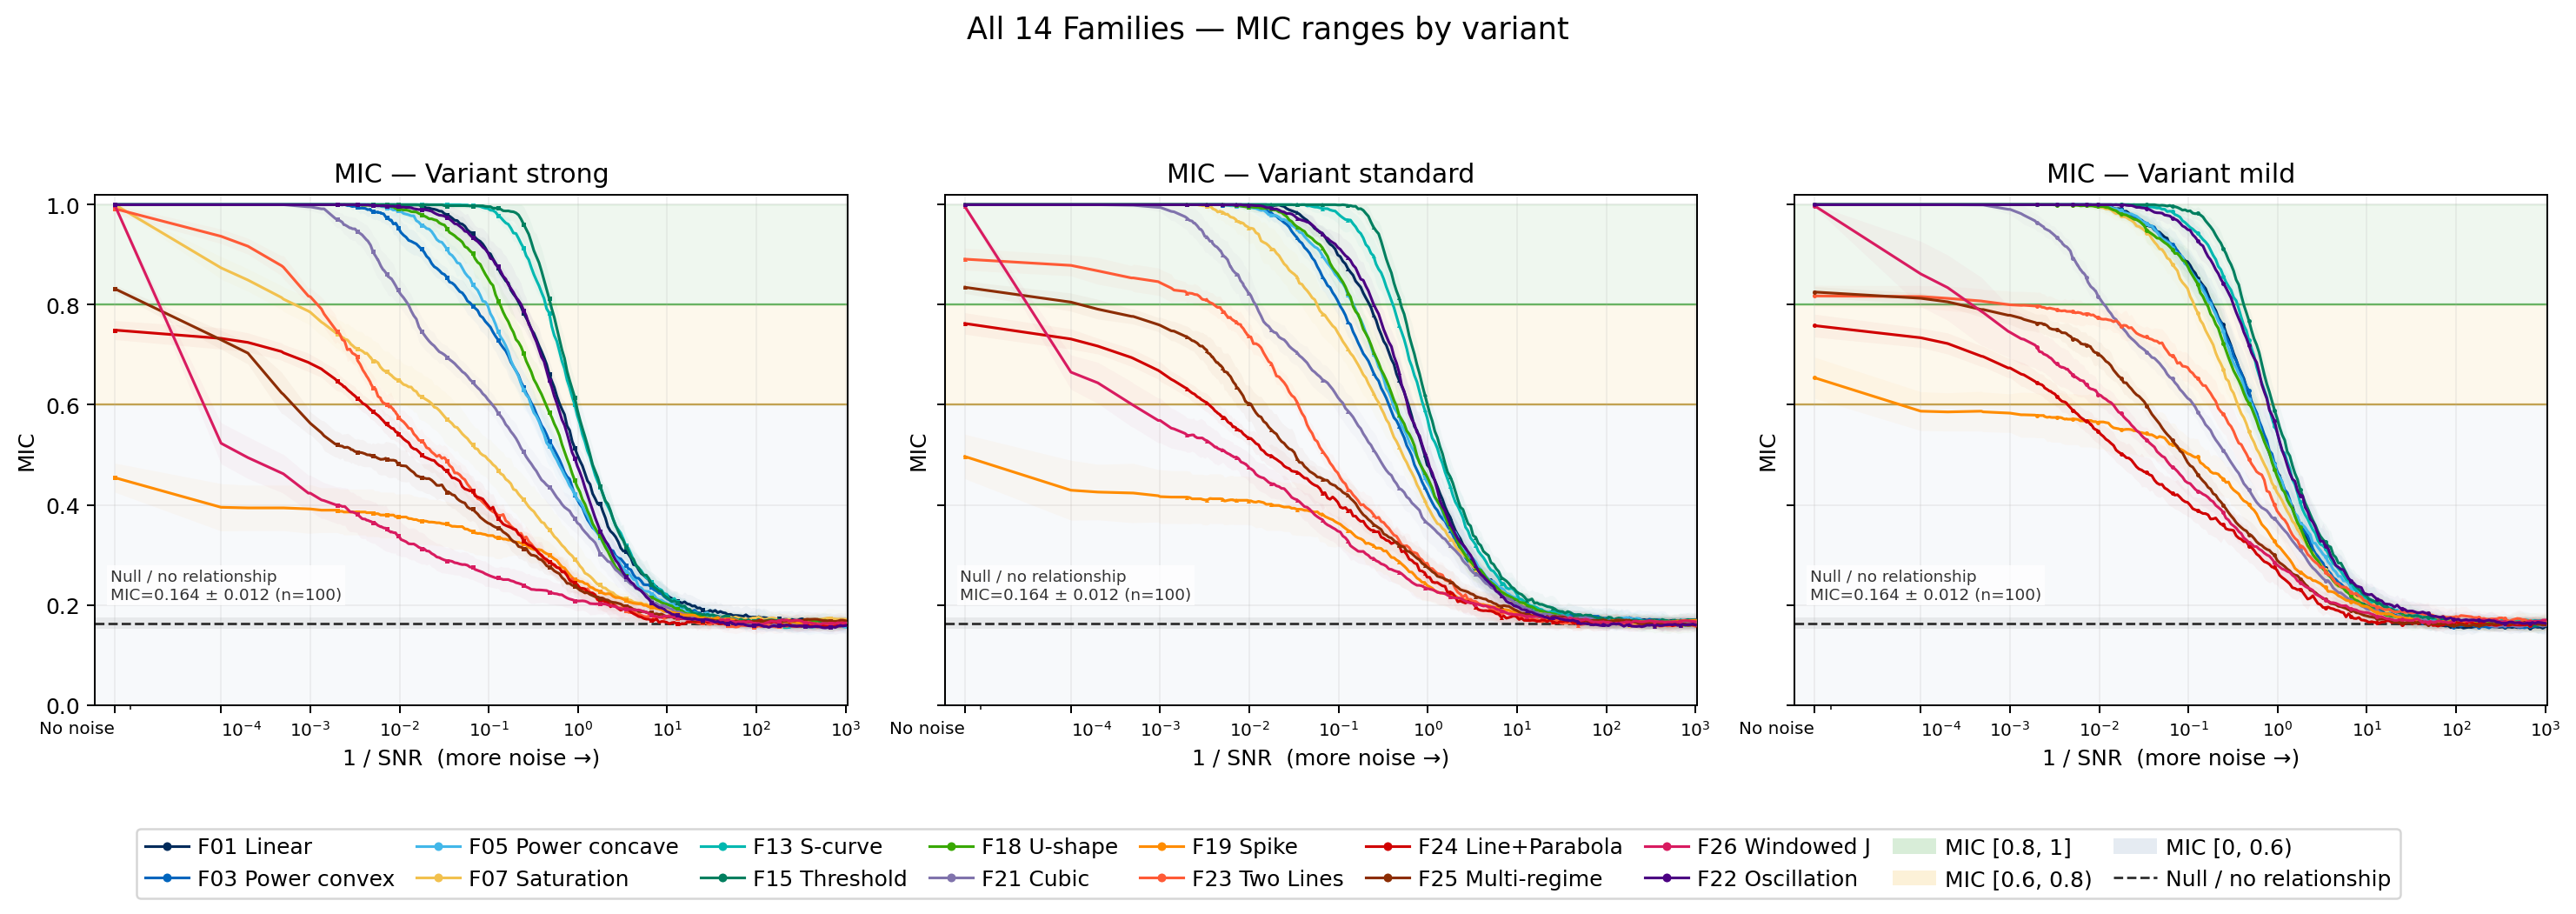

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


FAMILY_ORDER = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
FAMILY_COLORS = {
    'F01': '#002B5B', 'F03': '#0065BD', 'F05': '#42B7E9',
    'F07': '#F2C14E', 'F13': '#00B8B0', 'F15': '#007F5F',
    'F18': '#38A800', 'F21': '#8073AC', 'F19': '#FF8C00',
    'F23': '#FF5A36', 'F24': '#D00000', 'F25': '#8C2D04',
    'F26': '#D81B60', 'F22': '#4B0082',
}
FAMILY_SHORT_LABELS = {
    'F01': 'F01 Linear', 'F03': 'F03 Power convex',
    'F05': 'F05 Power concave', 'F07': 'F07 Saturation',
    'F13': 'F13 S-curve', 'F15': 'F15 Threshold',
    'F18': 'F18 U-shape', 'F21': 'F21 Cubic',
    'F19': 'F19 Spike', 'F23': 'F23 Two Lines',
    'F24': 'F24 Line+Parabola', 'F25': 'F25 Multi-regime',
    'F26': 'F26 Windowed J', 'F22': 'F22 Oscillation',
}
VARIANT_MARKERS = {'strong': 's', 'standard': '^', 'mild': 'o'}
RANGE_COLORS = {
    'high': '#2CA02C',
    'middle': '#F2C14E',
    'low': '#4C78A8',
}
NULL_COLOR = '#333333'

plot_signal = data.loc[
    (~data['is_null']) & data['variant_level'].isin(PLOT_VARIANTS)
].copy()
if PLOT_REPEATS is not None:
    plot_signal = plot_signal.loc[plot_signal['repeat'].isin(PLOT_REPEATS)].copy()

available_plot_variants = set(plot_signal['variant_level'].dropna().unique())
missing_plot_variants = set(PLOT_VARIANTS).difference(available_plot_variants)
if missing_plot_variants:
    raise ValueError(f'Plot variants not found: {sorted(missing_plot_variants)}')

plot_summary = (
    plot_signal.groupby(
        ['variant_level', 'family_id', 'inverse_snr'], as_index=False
    )['MIC']
    .agg(MIC_mean='mean', MIC_sd='std', n='size')
    .sort_values(['variant_level', 'family_id', 'inverse_snr'])
)
plot_summary['MIC_sd'] = plot_summary['MIC_sd'].fillna(0.0)

positive_inverse_snr = plot_summary.loc[
    plot_summary['inverse_snr'] > 0, 'inverse_snr'
]
MIN_POSITIVE_INVERSE_SNR = float(positive_inverse_snr.min())
MAX_INVERSE_SNR = float(positive_inverse_snr.max())
SYMLOG_LINTHRESH = MIN_POSITIVE_INVERSE_SNR / 2.0

null_case_ids = set(cases.loc[cases['is_null'], 'case_id'])
null_values = metrics.loc[metrics['case_id'].isin(null_case_ids), 'MIC'].dropna()
NULL_MIC_MEAN = float(null_values.mean())
NULL_MIC_SD = float(null_values.std())
NULL_MIC_N = int(null_values.size)

family_order = [
    family_id for family_id in FAMILY_ORDER
    if family_id in set(plot_summary['family_id'])
]


def format_mic_range_axis(ax, variant_level: str) -> None:
    ax.axhspan(MIC_HIGH_MIN, MIC_MAX, color=RANGE_COLORS['high'], alpha=0.075, zorder=0)
    ax.axhspan(MIC_MID_MIN, MIC_HIGH_MIN, color=RANGE_COLORS['middle'], alpha=0.10, zorder=0)
    ax.axhspan(MIC_MIN, MIC_MID_MIN, color=RANGE_COLORS['low'], alpha=0.045, zorder=0)
    ax.axhline(MIC_HIGH_MIN, color=RANGE_COLORS['high'], linewidth=0.9, alpha=0.75, zorder=1)
    ax.axhline(MIC_MID_MIN, color='#B8860B', linewidth=0.9, alpha=0.75, zorder=1)

    ax.set_xscale('symlog', base=10, linthresh=SYMLOG_LINTHRESH, linscale=0.8)
    ax.set_xlim(-0.25 * SYMLOG_LINTHRESH, 1.05 * MAX_INVERSE_SNR)
    decade_min = int(np.floor(np.log10(MIN_POSITIVE_INVERSE_SNR)))
    decade_max = int(np.ceil(np.log10(MAX_INVERSE_SNR)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ax.set_xticks(np.concatenate(([0.0], decade_ticks)))
    tick_labels = ax.set_xticklabels(
        ['No noise'] + [rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)]
    )
    tick_labels[0].set_ha('right')
    if len(tick_labels) > 1:
        tick_labels[1].set_ha('left')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_ylim(MIC_MIN, MIC_MAX + 0.02)
    ax.set_xlabel('1 / SNR  (more noise →)')
    ax.set_ylabel('MIC')
    ax.set_title(f'MIC — Variant {variant_level}')
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.22, linewidth=0.6)

    ax.axhspan(
        max(MIC_MIN, NULL_MIC_MEAN - NULL_MIC_SD),
        min(MIC_MAX, NULL_MIC_MEAN + NULL_MIC_SD),
        color=NULL_COLOR, alpha=0.08, linewidth=0, zorder=1,
    )
    ax.axhline(
        NULL_MIC_MEAN, color=NULL_COLOR, linestyle='--', linewidth=1.15, zorder=2
    )
    ax.text(
        0.02, min(0.92, NULL_MIC_MEAN + NULL_MIC_SD + 0.03),
        f'Null / no relationship\nMIC={NULL_MIC_MEAN:.3f} ± {NULL_MIC_SD:.3f} (n={NULL_MIC_N})',
        transform=ax.get_yaxis_transform(), ha='left', va='bottom', fontsize=7.4,
        color=NULL_COLOR, zorder=5,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.5},
    )


def draw_variant_mic_profiles(ax, variant_level: str) -> None:
    variant_points = plot_summary.loc[plot_summary['variant_level'].eq(variant_level)]
    for family_id in family_order:
        points = variant_points.loc[variant_points['family_id'].eq(family_id)]
        if points.empty:
            continue
        x = points['inverse_snr'].to_numpy()
        mean = points['MIC_mean'].to_numpy()
        sd = points['MIC_sd'].to_numpy()
        color = FAMILY_COLORS[family_id]
        ax.fill_between(
            x, np.clip(mean - sd, MIC_MIN, MIC_MAX), np.clip(mean + sd, MIC_MIN, MIC_MAX),
            color=color, alpha=0.035, linewidth=0, zorder=2,
        )
        ax.plot(
            x, mean, color=color, linewidth=1.25,
            marker=VARIANT_MARKERS[variant_level], markersize=2.0, markevery=10,
            markeredgewidth=0, label=FAMILY_SHORT_LABELS[family_id], zorder=3,
        )
    format_mic_range_axis(ax, variant_level)


family_handles = [
    Line2D([0], [0], color=FAMILY_COLORS[family_id], marker='o',
           linewidth=1.25, markersize=4, markeredgewidth=0,
           label=FAMILY_SHORT_LABELS[family_id])
    for family_id in family_order
]
range_handles = [
    Patch(facecolor=RANGE_COLORS['high'], alpha=0.18,
          label=f'MIC [{MIC_HIGH_MIN:g}, {MIC_MAX:g}]'),
    Patch(facecolor=RANGE_COLORS['middle'], alpha=0.22,
          label=f'MIC [{MIC_MID_MIN:g}, {MIC_HIGH_MIN:g})'),
    Patch(facecolor=RANGE_COLORS['low'], alpha=0.14,
          label=f'MIC [{MIC_MIN:g}, {MIC_MID_MIN:g})'),
    Line2D([0], [0], color=NULL_COLOR, linestyle='--', linewidth=1.15,
           label='Null / no relationship'),
]

FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figure_paths = []

if SAVE_MIC_RANGE_FIGURES:
    for variant_level in PLOT_VARIANTS:
        fig, ax = plt.subplots(figsize=(7.4, 6.2))
        draw_variant_mic_profiles(ax, variant_level)
        fig.suptitle(f'All {len(family_order)} Families — MIC ranges', y=0.99, fontsize=13)
        variant_handle = Line2D(
            [0], [0], color='#777777', marker=VARIANT_MARKERS[variant_level],
            linewidth=0, markersize=5, label=f'Variant {variant_level}',
        )
        fig.legend(
            handles=family_handles + range_handles + [variant_handle],
            loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=5,
            frameon=True, fontsize=8, columnspacing=0.9, handletextpad=0.35,
        )
        fig.tight_layout(rect=[0.03, 0.20, 0.99, 0.92])
        figure_path = FIGURE_DIR / f'mic_ranges_{variant_level}.png'
        fig.savefig(figure_path, dpi=FIGURE_DPI, bbox_inches='tight')
        plt.close(fig)
        figure_paths.append(figure_path)

    fig, axes = plt.subplots(1, len(PLOT_VARIANTS), figsize=(17.0, 5.8), sharey=True)
    if len(PLOT_VARIANTS) == 1:
        axes = [axes]
    for ax, variant_level in zip(axes, PLOT_VARIANTS):
        draw_variant_mic_profiles(ax, variant_level)
    fig.suptitle(f'All {len(family_order)} Families — MIC ranges by variant', y=0.995, fontsize=14)
    fig.legend(
        handles=family_handles + range_handles,
        loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=9,
        frameon=True, fontsize=10, columnspacing=1.0, handletextpad=0.4,
    )
    fig.tight_layout(rect=[0.02, 0.13, 0.995, 0.92])
    combined_figure_path = FIGURE_DIR / 'mic_ranges_all_variants_1x3.png'
    fig.savefig(combined_figure_path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.close(fig)
    figure_paths.append(combined_figure_path)

print('Saved MIC range figures:')
for path in figure_paths:
    print(f'  {path.relative_to(REPO_ROOT)}')

if figure_paths:
    strong_figure_path = FIGURE_DIR / 'mic_ranges_strong.png'
    print('\nStrong only:')
    display(Image(filename=str(strong_figure_path)))
    print('\nAll variants:')
    display(Image(filename=str(figure_paths[-1])))

## Simple or Complex after the high-MIC filter

First retain signal scatterplots with `MIC >= MIC_HIGH_MIN` (default 0.8). Within that high-MIC subset, label a case **Simple** only when both `|Spearman rho|` and `|Pearson r|` are at least `SIMPLE_COMPLEX_CORRELATION_THRESHOLD` (default 0.7); otherwise label it **Complex**.

In [7]:
if not (0.0 <= SIMPLE_COMPLEX_CORRELATION_THRESHOLD <= 1.0):
    raise ValueError(
        'SIMPLE_COMPLEX_CORRELATION_THRESHOLD must fall inside [0, 1].'
    )

simple_complex = data.loc[
    (~data['is_null']) & (data['MIC'] >= MIC_HIGH_MIN)
].drop(columns=['_MIC_for_filter'], errors='ignore').copy()
simple_complex['input_MIC_threshold'] = MIC_HIGH_MIN
simple_complex['simple_complex_correlation_threshold'] = (
    SIMPLE_COMPLEX_CORRELATION_THRESHOLD
)
simple_complex['passes_spearman_threshold'] = (
    simple_complex['spearman_rho'].abs() >= SIMPLE_COMPLEX_CORRELATION_THRESHOLD
)
simple_complex['passes_pearson_threshold'] = (
    simple_complex['pearson_r'].abs() >= SIMPLE_COMPLEX_CORRELATION_THRESHOLD
)
simple_complex['passes_simple_correlation_rule'] = (
    simple_complex['passes_spearman_threshold']
    & simple_complex['passes_pearson_threshold']
)
simple_complex['simple_complex_label'] = np.where(
    simple_complex['passes_simple_correlation_rule'], 'Simple', 'Complex'
)
simple_complex['variant_group'] = simple_complex['variant_level']

simple_complex_summary = (
    simple_complex.groupby(
        ['variant_group', 'simple_complex_label'], as_index=False, dropna=False
    )
    .agg(
        n_cases=('case_id', 'size'),
        MIC_min=('MIC', 'min'),
        MIC_mean=('MIC', 'mean'),
        MIC_max=('MIC', 'max'),
    )
)
simple_complex_summary['share_within_variant'] = (
    simple_complex_summary['n_cases']
    / simple_complex_summary.groupby('variant_group')['n_cases'].transform('sum')
)

simple_complex_family_summary = (
    simple_complex.groupby(
        ['family_id', 'family_name', 'variant_group', 'simple_complex_label'],
        as_index=False,
        dropna=False,
    )
    .agg(
        n_cases=('case_id', 'size'),
        MIC_min=('MIC', 'min'),
        MIC_mean=('MIC', 'mean'),
        MIC_max=('MIC', 'max'),
    )
)
simple_complex_family_summary['share_within_family_variant'] = (
    simple_complex_family_summary['n_cases']
    / simple_complex_family_summary.groupby(
        ['family_id', 'variant_group']
    )['n_cases'].transform('sum')
)

simple_complex_saved_paths = []
if SAVE_SIMPLE_COMPLEX_RESULTS:
    simple_complex_stem = f'simple_complex_after_mic_ge_{number_token(MIC_HIGH_MIN)}'
    full_path = OUTPUT_DIR / f'{simple_complex_stem}_full.parquet'
    manifest_path = OUTPUT_DIR / f'{simple_complex_stem}_manifest.csv'
    summary_path = OUTPUT_DIR / f'{simple_complex_stem}_summary.csv'
    family_summary_path = OUTPUT_DIR / f'{simple_complex_stem}_family_summary.csv'

    if not OVERWRITE:
        existing_paths = [
            path for path in [full_path, manifest_path, summary_path, family_summary_path]
            if path.exists()
        ]
        if existing_paths:
            raise FileExistsError(existing_paths[0])

    simple_complex.to_parquet(full_path, index=False)

    simple_complex_manifest_columns = [
        'case_id', 'trajectory_id', 'family_id', 'family_name',
        'variant_name', 'variant_level', 'repeat', 'nominal_snr',
        'actual_snr', 'inverse_snr', 'is_null', 'MIC',
        'pearson_r', 'spearman_rho', 'input_MIC_threshold',
        'simple_complex_correlation_threshold',
        'passes_spearman_threshold', 'passes_pearson_threshold',
        'passes_simple_correlation_rule', 'simple_complex_label',
    ]
    simple_complex_manifest_columns = [
        column for column in simple_complex_manifest_columns
        if column in simple_complex.columns
    ]
    simple_complex.loc[:, simple_complex_manifest_columns].to_csv(
        manifest_path, index=False
    )
    simple_complex_summary.to_csv(summary_path, index=False)
    simple_complex_family_summary.to_csv(family_summary_path, index=False)
    simple_complex_saved_paths.extend(
        [full_path, manifest_path, summary_path, family_summary_path]
    )

overall_counts = simple_complex['simple_complex_label'].value_counts()
n_signal_classified = len(simple_complex)

print('Simple / Complex after the high-MIC filter')
print(f'  Input: MIC >= {MIC_HIGH_MIN:g}')
print(
    f'  Simple: |Spearman rho| >= {SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g} '
    f'AND |Pearson r| >= {SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g}'
)
for label in ['Simple', 'Complex']:
    count = int(overall_counts.get(label, 0))
    share = count / n_signal_classified if n_signal_classified else np.nan
    print(f'  {label:<7}: {count:>7,} / {n_signal_classified:,} ({share:.1%})')

print('\nBy variant:')
display(
    simple_complex_summary.pivot(
        index='variant_group', columns='simple_complex_label', values='n_cases'
    ).fillna(0).astype(int)
)

if simple_complex_saved_paths:
    print('Saved:')
    for path in simple_complex_saved_paths:
        print(f'  {path.relative_to(REPO_ROOT)}')

Simple / Complex after the high-MIC filter
  Input: MIC >= 0.8
  Simple: |Spearman rho| >= 0.7 AND |Pearson r| >= 0.7
  Simple :  18,669 / 24,643 (75.8%)
  Complex:   5,974 / 24,643 (24.2%)

By variant:


simple_complex_label,Complex,Simple
variant_group,,
mild,1208,7498
standard,2400,6080
strong,2366,5091


Saved:
  E/output/S4_mic_range_filter/simple_complex_after_mic_ge_0p8_full.parquet
  E/output/S4_mic_range_filter/simple_complex_after_mic_ge_0p8_manifest.csv
  E/output/S4_mic_range_filter/simple_complex_after_mic_ge_0p8_summary.csv
  E/output/S4_mic_range_filter/simple_complex_after_mic_ge_0p8_family_summary.csv


## Pearson and Spearman profiles after `MIC >= 0.8`

These two figures use only the high-MIC cases selected above. Values are plotted as absolute correlations because the Simple rule uses `|rho|` and `|r|`.

Saved high-MIC correlation figures:
  E/output/S4_mic_range_filter/figures/spearman_after_high_mic_mic_ge_0p8.png


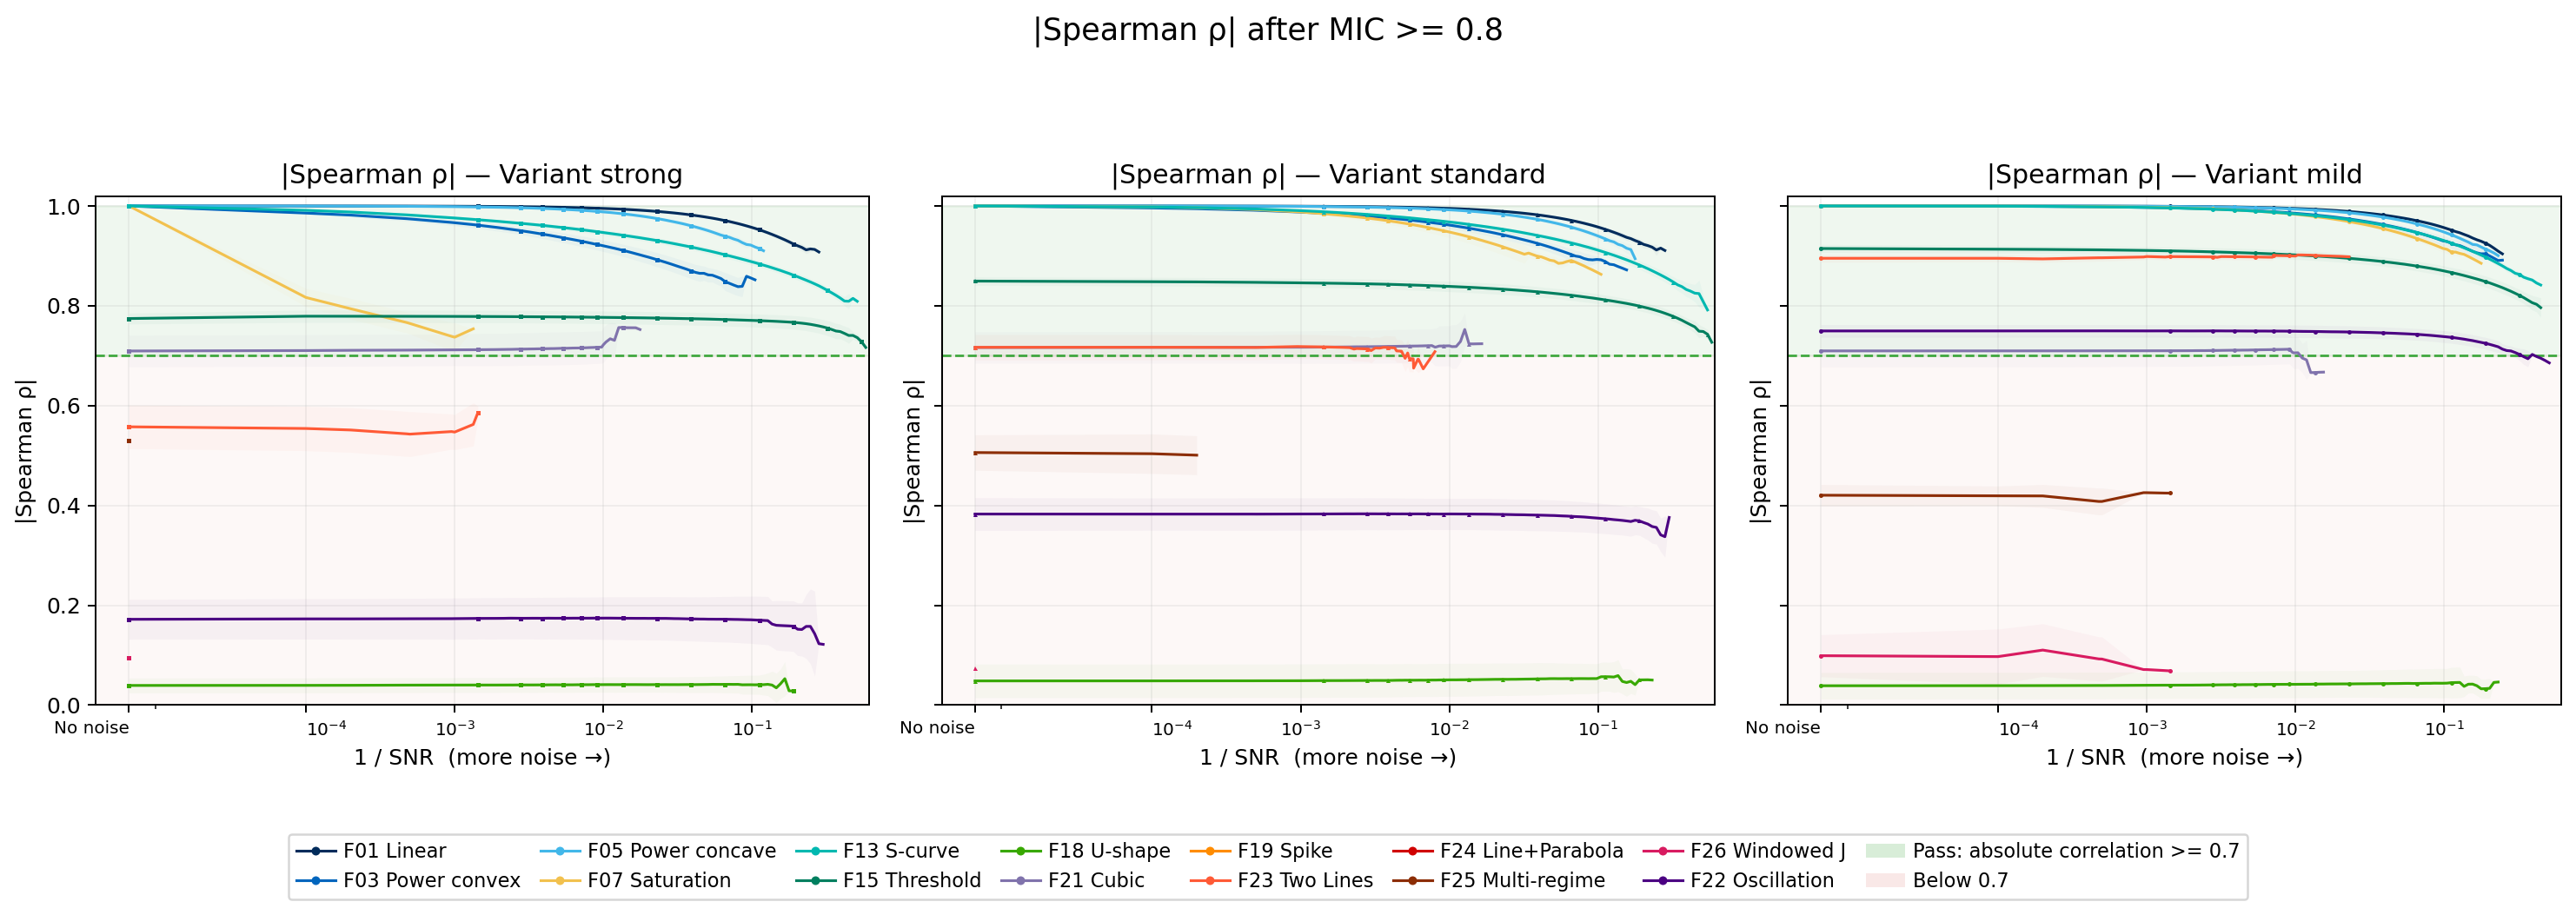

  E/output/S4_mic_range_filter/figures/pearson_after_high_mic_mic_ge_0p8.png


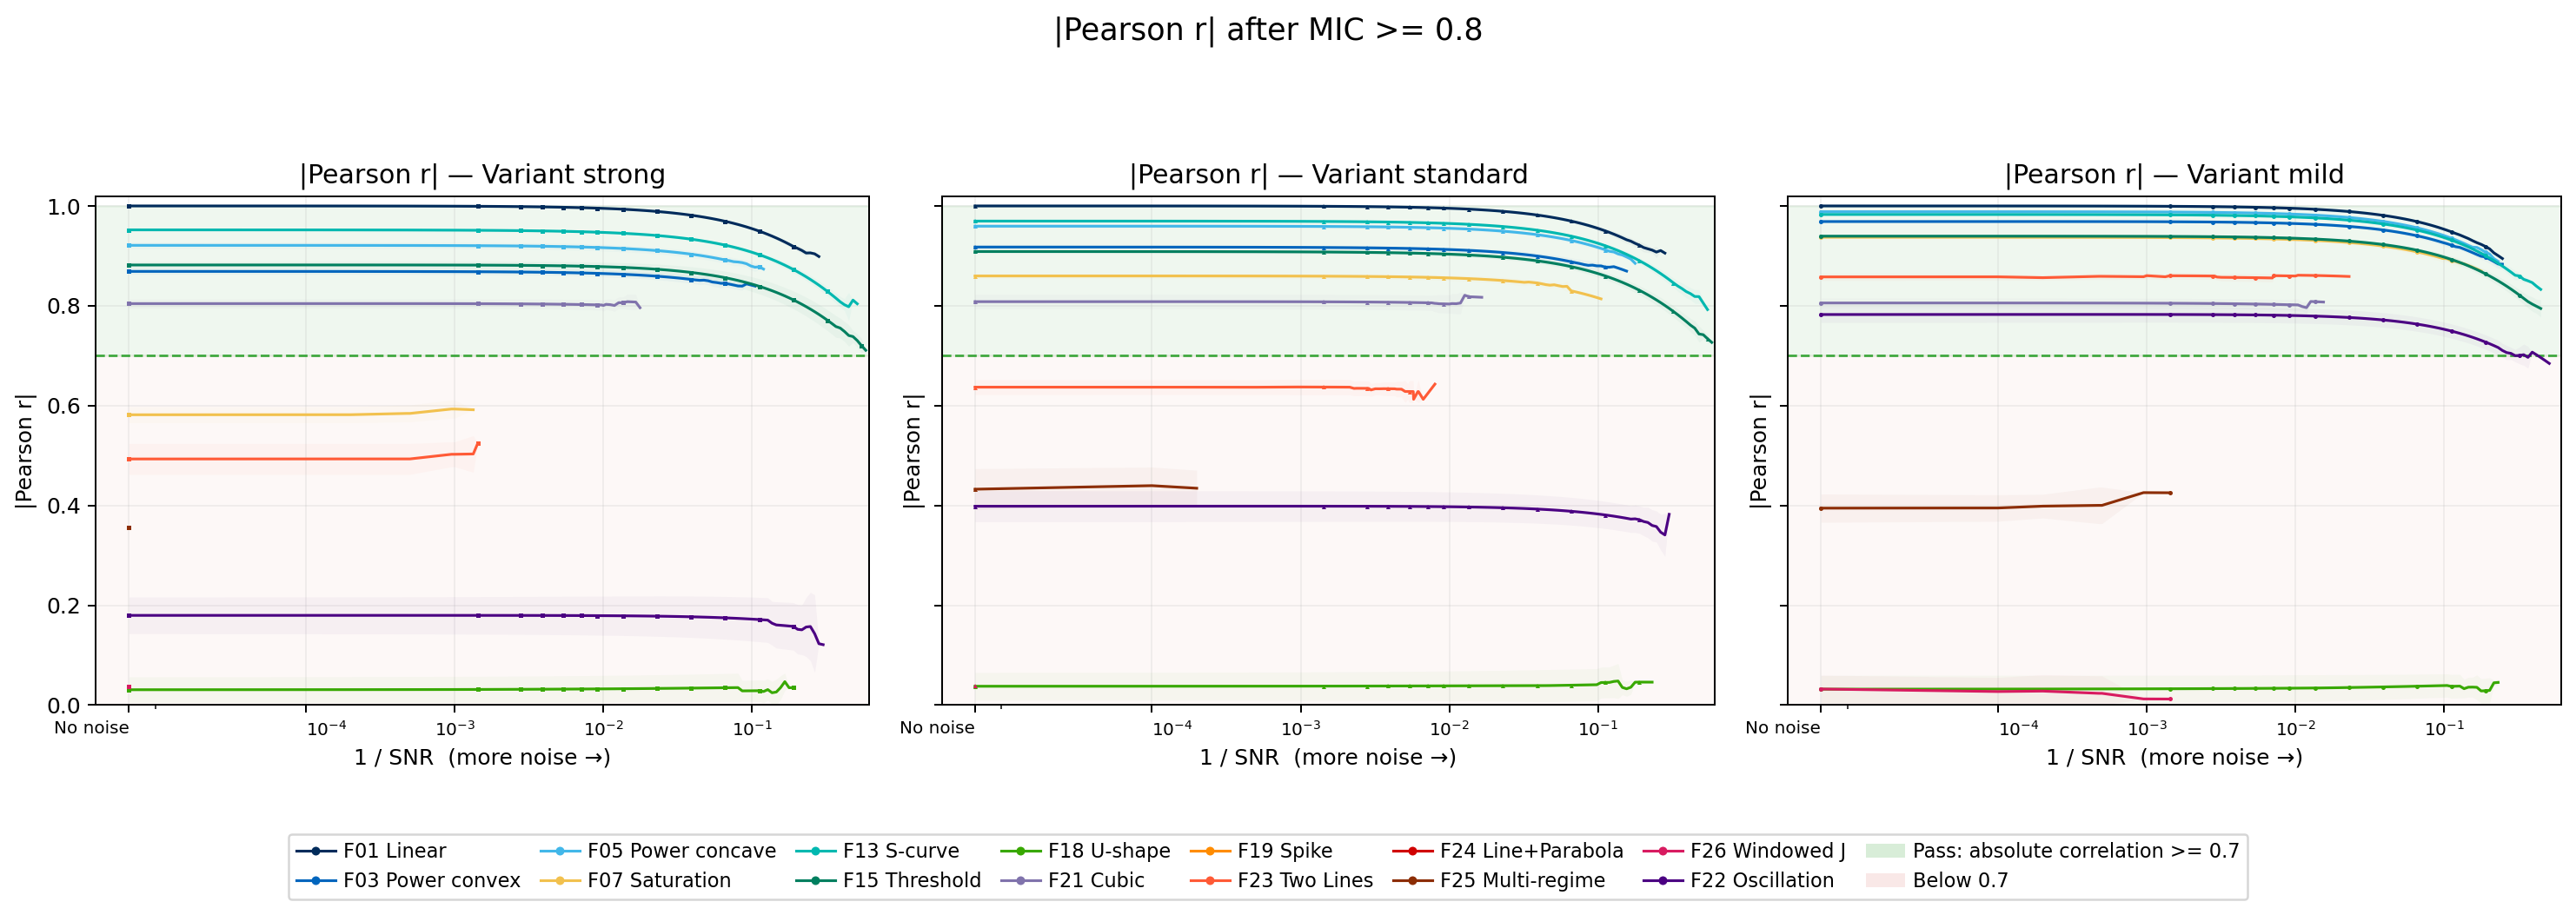

In [8]:
CORRELATION_FIGURE_SPECS = [
    ('spearman_rho', '|Spearman ρ|', 'spearman_after_high_mic'),
    ('pearson_r', '|Pearson r|', 'pearson_after_high_mic'),
]
CORRELATION_PASS_COLOR = '#2CA02C'
CORRELATION_FAIL_COLOR = '#D95F59'

high_mic_for_plot = simple_complex.copy()
if PLOT_REPEATS is not None:
    high_mic_for_plot = high_mic_for_plot.loc[
        high_mic_for_plot['repeat'].isin(PLOT_REPEATS)
    ].copy()

HIGH_MIC_MIN_POSITIVE_INVERSE_SNR = float(
    high_mic_for_plot.loc[
        high_mic_for_plot['inverse_snr'] > 0, 'inverse_snr'
    ].min()
)
HIGH_MIC_MAX_INVERSE_SNR = float(high_mic_for_plot['inverse_snr'].max())
HIGH_MIC_SYMLOG_LINTHRESH = HIGH_MIC_MIN_POSITIVE_INVERSE_SNR / 2.0


def build_high_mic_correlation_summary(metric_column: str) -> pd.DataFrame:
    points = high_mic_for_plot.loc[:, [
        'variant_level', 'family_id', 'inverse_snr', metric_column
    ]].copy()
    points['absolute_metric'] = points[metric_column].abs()
    return (
        points.groupby(
            ['variant_level', 'family_id', 'inverse_snr'], as_index=False
        )['absolute_metric']
        .agg(metric_mean='mean', metric_sd='std', n='size')
        .sort_values(['variant_level', 'family_id', 'inverse_snr'])
        .fillna({'metric_sd': 0.0})
    )


def format_high_mic_correlation_axis(ax, variant_level: str, metric_label: str) -> None:
    threshold = SIMPLE_COMPLEX_CORRELATION_THRESHOLD
    ax.axhspan(threshold, 1.0, color=CORRELATION_PASS_COLOR, alpha=0.075, zorder=0)
    ax.axhspan(0.0, threshold, color=CORRELATION_FAIL_COLOR, alpha=0.045, zorder=0)
    ax.axhline(
        threshold, color=CORRELATION_PASS_COLOR, linestyle='--',
        linewidth=1.1, alpha=0.9, zorder=2,
    )

    ax.set_xscale(
        'symlog', base=10, linthresh=HIGH_MIC_SYMLOG_LINTHRESH, linscale=0.8
    )
    decade_min = int(np.floor(np.log10(HIGH_MIC_MIN_POSITIVE_INVERSE_SNR)))
    decade_max = int(np.floor(np.log10(HIGH_MIC_MAX_INVERSE_SNR)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ax.set_xticks(np.concatenate(([0.0], decade_ticks)))
    tick_labels = ax.set_xticklabels(
        ['No noise']
        + [rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)]
    )
    tick_labels[0].set_ha('right')
    if len(tick_labels) > 1:
        tick_labels[1].set_ha('left')
    ax.set_xlim(
        -0.25 * HIGH_MIC_SYMLOG_LINTHRESH,
        1.05 * HIGH_MIC_MAX_INVERSE_SNR,
    )
    ax.set_ylim(0.0, 1.02)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel('1 / SNR  (more noise →)')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} — Variant {variant_level}')
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.22, linewidth=0.6)


def draw_high_mic_correlation_profiles(
    ax, summary_frame: pd.DataFrame, variant_level: str, metric_label: str
) -> None:
    variant_points = summary_frame.loc[
        summary_frame['variant_level'].eq(variant_level)
    ]
    for family_id in family_order:
        points = variant_points.loc[variant_points['family_id'].eq(family_id)]
        if points.empty:
            continue
        x = points['inverse_snr'].to_numpy()
        mean = points['metric_mean'].to_numpy()
        sd = points['metric_sd'].to_numpy()
        color = FAMILY_COLORS[family_id]
        ax.fill_between(
            x, np.clip(mean - sd, 0.0, 1.0), np.clip(mean + sd, 0.0, 1.0),
            color=color, alpha=0.035, linewidth=0, zorder=2,
        )
        ax.plot(
            x, mean, color=color, linewidth=1.25,
            marker=VARIANT_MARKERS[variant_level], markersize=2.0, markevery=8,
            markeredgewidth=0, zorder=3,
        )
    format_high_mic_correlation_axis(ax, variant_level, metric_label)


correlation_threshold_handles = [
    Patch(
        facecolor=CORRELATION_PASS_COLOR, alpha=0.18,
        label=f'Pass: absolute correlation >= {SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g}',
    ),
    Patch(
        facecolor=CORRELATION_FAIL_COLOR, alpha=0.14,
        label=f'Below {SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g}',
    ),
]

correlation_figure_paths = []
for metric_column, metric_label, file_stem in CORRELATION_FIGURE_SPECS:
    metric_summary = build_high_mic_correlation_summary(metric_column)
    fig, axes = plt.subplots(
        1, len(PLOT_VARIANTS), figsize=(17.0, 5.8), sharey=True
    )
    if len(PLOT_VARIANTS) == 1:
        axes = [axes]
    for ax, variant_level in zip(axes, PLOT_VARIANTS):
        draw_high_mic_correlation_profiles(
            ax, metric_summary, variant_level, metric_label
        )
    fig.suptitle(
        f'{metric_label} after MIC >= {MIC_HIGH_MIN:g}', y=0.995, fontsize=14
    )
    fig.legend(
        handles=family_handles + correlation_threshold_handles,
        loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=8,
        frameon=True, fontsize=9, columnspacing=1.0, handletextpad=0.4,
    )
    fig.tight_layout(rect=[0.02, 0.13, 0.995, 0.92])
    figure_path = FIGURE_DIR / f'{file_stem}_mic_ge_{number_token(MIC_HIGH_MIN)}.png'
    fig.savefig(figure_path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.close(fig)
    correlation_figure_paths.append(figure_path)

print('Saved high-MIC correlation figures:')
for path in correlation_figure_paths:
    print(f'  {path.relative_to(REPO_ROOT)}')
    display(Image(filename=str(path)))

## Four strong-only correlation figures

The first two figures retain only scatterplots with `MIC > 0.8`. The other two use all non-null strong scatterplots without applying an MIC filter.

Saved four strong-only correlation figures:
  MIC > 0.8: 7,457 scatterplots
  All strong: 31,780 scatterplots
  E/output/S4_mic_range_filter/figures/strong_pearson_mic_gt_0p8.png


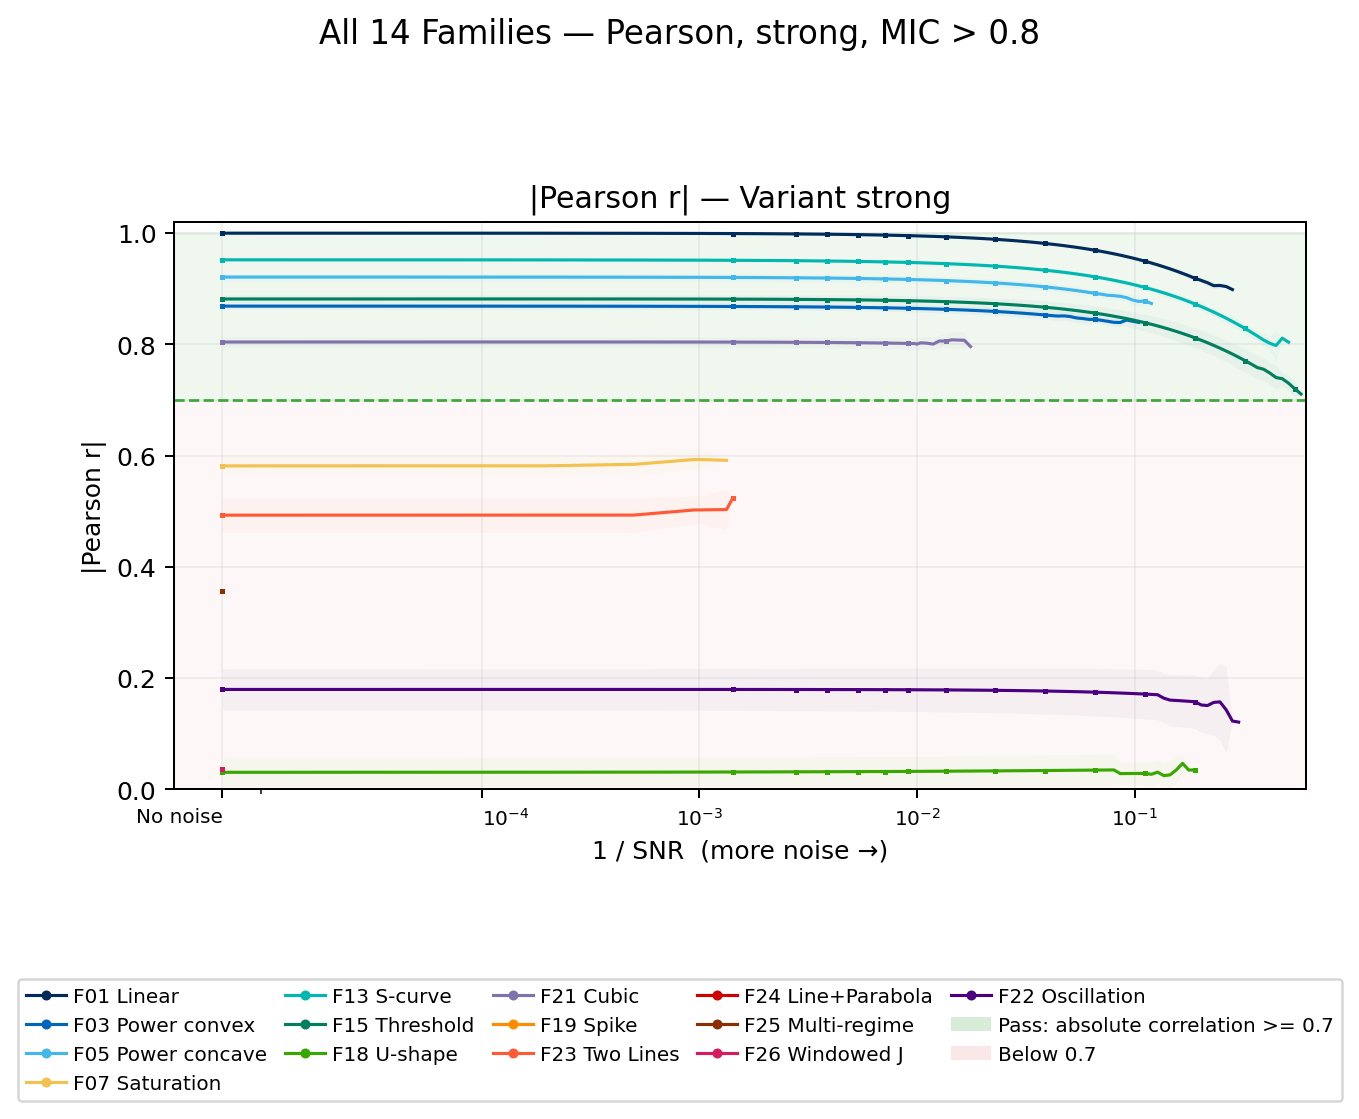

  E/output/S4_mic_range_filter/figures/strong_spearman_mic_gt_0p8.png


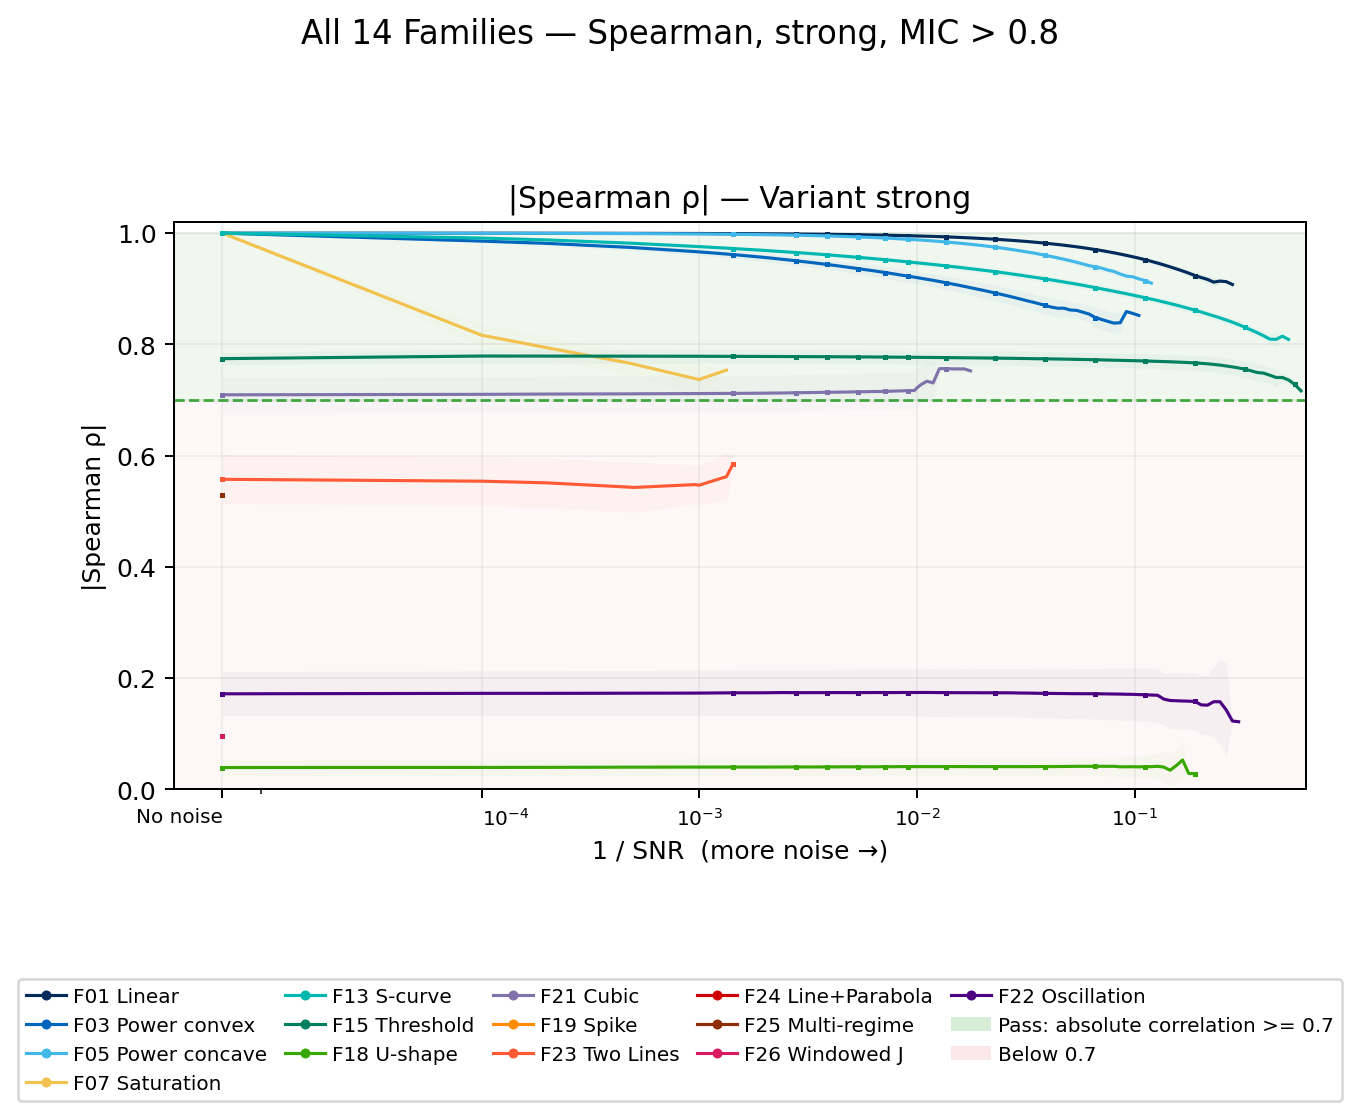

  E/output/S4_mic_range_filter/figures/strong_pearson_all_scatterplots.png


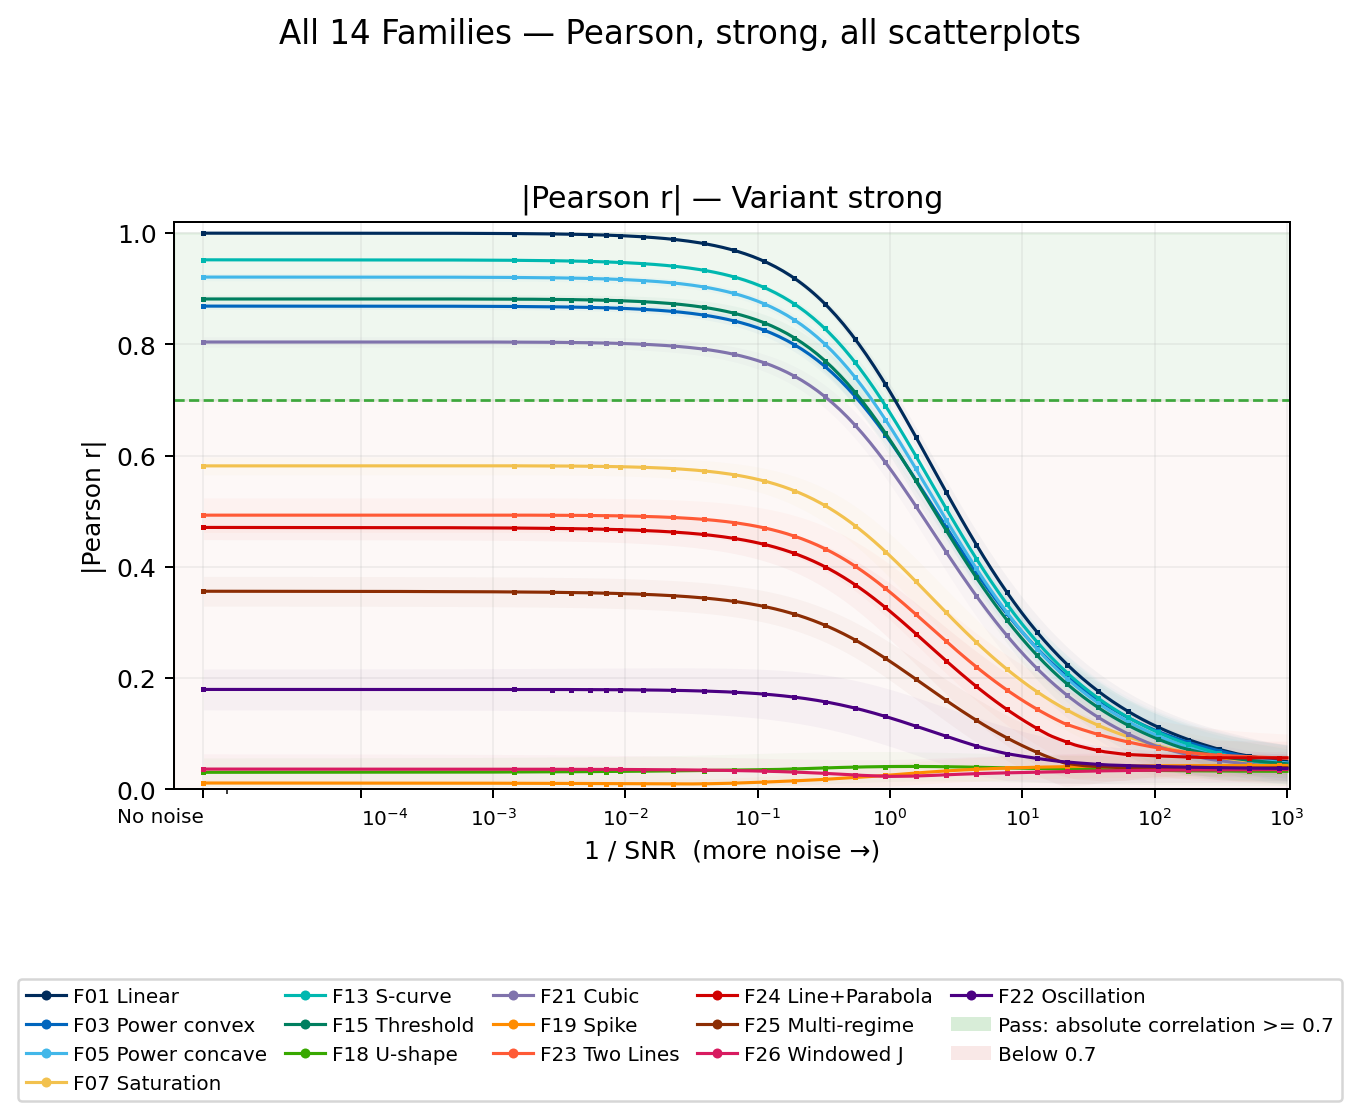

  E/output/S4_mic_range_filter/figures/strong_spearman_all_scatterplots.png


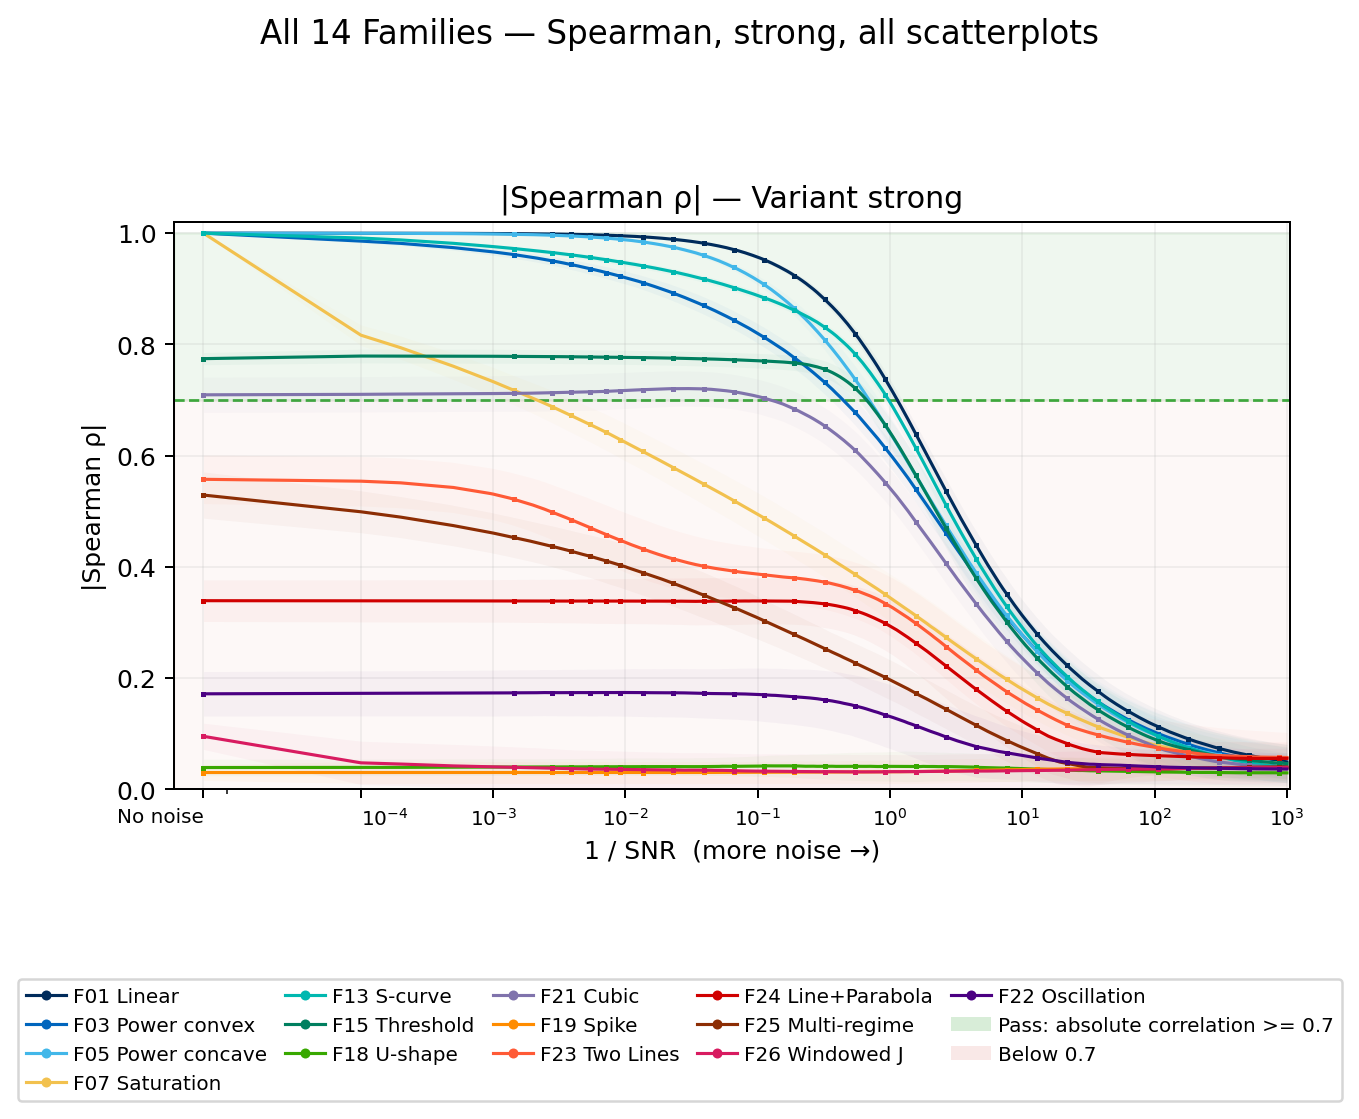

In [9]:
# Four separate strong-only figures:
#   1–2. Pearson and Spearman after the strict MIC > 0.8 filter.
#   3–4. Pearson and Spearman for every non-null strong scatterplot.
strong_all_scatterplots = data.loc[
    (~data['is_null']) & data['variant_level'].eq('strong')
].drop(columns=['_MIC_for_filter'], errors='ignore').copy()
if PLOT_REPEATS is not None:
    strong_all_scatterplots = strong_all_scatterplots.loc[
        strong_all_scatterplots['repeat'].isin(PLOT_REPEATS)
    ].copy()

strong_mic_gt_high = strong_all_scatterplots.loc[
    strong_all_scatterplots['MIC'] > MIC_HIGH_MIN
].copy()


def build_strong_correlation_summary(
    source_frame: pd.DataFrame, metric_column: str
) -> pd.DataFrame:
    points = source_frame.loc[:, [
        'family_id', 'inverse_snr', metric_column
    ]].copy()
    points['absolute_metric'] = points[metric_column].abs()
    return (
        points.groupby(['family_id', 'inverse_snr'], as_index=False)
        ['absolute_metric']
        .agg(metric_mean='mean', metric_sd='std', n='size')
        .sort_values(['family_id', 'inverse_snr'])
        .fillna({'metric_sd': 0.0})
    )


def draw_strong_correlation_figure(
    source_frame: pd.DataFrame,
    metric_column: str,
    metric_label: str,
    selection_label: str,
    output_filename: str,
) -> Path:
    if source_frame.empty:
        raise ValueError(f'No rows available for {selection_label}.')

    summary = build_strong_correlation_summary(source_frame, metric_column)
    positive_x = summary.loc[summary['inverse_snr'] > 0, 'inverse_snr']
    min_positive_x = float(positive_x.min())
    max_x = float(summary['inverse_snr'].max())
    symlog_linthresh = min_positive_x / 2.0

    fig, ax = plt.subplots(figsize=(7.4, 6.2))
    threshold = SIMPLE_COMPLEX_CORRELATION_THRESHOLD
    ax.axhspan(
        threshold, 1.0, color=CORRELATION_PASS_COLOR, alpha=0.075, zorder=0
    )
    ax.axhspan(
        0.0, threshold, color=CORRELATION_FAIL_COLOR, alpha=0.045, zorder=0
    )
    ax.axhline(
        threshold, color=CORRELATION_PASS_COLOR, linestyle='--',
        linewidth=1.1, alpha=0.9, zorder=2,
    )

    for family_id in family_order:
        family_points = summary.loc[summary['family_id'].eq(family_id)]
        if family_points.empty:
            continue
        x = family_points['inverse_snr'].to_numpy()
        mean = family_points['metric_mean'].to_numpy()
        sd = family_points['metric_sd'].to_numpy()
        color = FAMILY_COLORS[family_id]
        ax.fill_between(
            x, np.clip(mean - sd, 0.0, 1.0), np.clip(mean + sd, 0.0, 1.0),
            color=color, alpha=0.035, linewidth=0, zorder=2,
        )
        ax.plot(
            x, mean, color=color, linewidth=1.25,
            marker=VARIANT_MARKERS['strong'], markersize=2.0,
            markevery=8, markeredgewidth=0, zorder=3,
        )

    ax.set_xscale(
        'symlog', base=10, linthresh=symlog_linthresh, linscale=0.8
    )
    decade_min = int(np.floor(np.log10(min_positive_x)))
    decade_max = int(np.ceil(np.log10(max_x)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ax.set_xticks(np.concatenate(([0.0], decade_ticks)))
    tick_labels = ax.set_xticklabels(
        ['No noise']
        + [rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)]
    )
    tick_labels[0].set_ha('right')
    if len(tick_labels) > 1:
        tick_labels[1].set_ha('left')
    ax.set_xlim(-0.25 * symlog_linthresh, 1.05 * max_x)
    ax.set_ylim(0.0, 1.02)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel('1 / SNR  (more noise →)')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} — Variant strong')
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.22, linewidth=0.6)

    fig.suptitle(
        f'All {len(family_order)} Families — {selection_label}',
        y=0.99, fontsize=13,
    )
    fig.legend(
        handles=family_handles + correlation_threshold_handles,
        loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=5,
        frameon=True, fontsize=8, columnspacing=0.9, handletextpad=0.35,
    )
    fig.tight_layout(rect=[0.03, 0.20, 0.99, 0.92])
    figure_path = FIGURE_DIR / output_filename
    fig.savefig(figure_path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.close(fig)
    return figure_path


strong_only_figure_specs = [
    (
        strong_mic_gt_high, 'pearson_r', '|Pearson r|',
        f'Pearson, strong, MIC > {MIC_HIGH_MIN:g}',
        f'strong_pearson_mic_gt_{number_token(MIC_HIGH_MIN)}.png',
    ),
    (
        strong_mic_gt_high, 'spearman_rho', '|Spearman ρ|',
        f'Spearman, strong, MIC > {MIC_HIGH_MIN:g}',
        f'strong_spearman_mic_gt_{number_token(MIC_HIGH_MIN)}.png',
    ),
    (
        strong_all_scatterplots, 'pearson_r', '|Pearson r|',
        'Pearson, strong, all scatterplots',
        'strong_pearson_all_scatterplots.png',
    ),
    (
        strong_all_scatterplots, 'spearman_rho', '|Spearman ρ|',
        'Spearman, strong, all scatterplots',
        'strong_spearman_all_scatterplots.png',
    ),
]

strong_only_figure_paths = [
    draw_strong_correlation_figure(*figure_spec)
    for figure_spec in strong_only_figure_specs
]

print('Saved four strong-only correlation figures:')
print(f'  MIC > {MIC_HIGH_MIN:g}: {len(strong_mic_gt_high):,} scatterplots')
print(f'  All strong: {len(strong_all_scatterplots):,} scatterplots')
for path in strong_only_figure_paths:
    print(f'  {path.relative_to(REPO_ROOT)}')
    display(Image(filename=str(path)))

## Strong monotonicity after the Simple correlation filter

Starting from scatterplots that pass `MIC >= 0.8`, `|Spearman rho| >= 0.7`, and `|Pearson r| >= 0.7`, strong positive monotonicity is defined as `Spearman rho >= 0.9`. The threshold is configured at the beginning of the notebook.

In [10]:
if not (0.0 <= STRONG_MONOTONICITY_SPEARMAN_THRESHOLD <= 1.0):
    raise ValueError(
        'STRONG_MONOTONICITY_SPEARMAN_THRESHOLD must fall inside [0, 1].'
    )

# Sequential input:
#   1. MIC >= 0.8 (simple_complex)
#   2. |Spearman rho| >= 0.7 AND |Pearson r| >= 0.7
#   3. Spearman rho >= 0.9 (Strong monotonicity)
strong_monotonicity_screen = simple_complex.loc[
    simple_complex['passes_simple_correlation_rule']
].copy()
strong_monotonicity_screen['strong_monotonicity_spearman_threshold'] = (
    STRONG_MONOTONICITY_SPEARMAN_THRESHOLD
)
strong_monotonicity_screen['passes_strong_monotonicity'] = (
    strong_monotonicity_screen['spearman_rho']
    >= STRONG_MONOTONICITY_SPEARMAN_THRESHOLD
)
strong_monotonicity_screen['strong_monotonicity_label'] = np.where(
    strong_monotonicity_screen['passes_strong_monotonicity'],
    'Strong monotonicity',
    'Below strong monotonicity',
)

strong_monotonicity = strong_monotonicity_screen.loc[
    strong_monotonicity_screen['passes_strong_monotonicity']
].copy()

strong_monotonicity_summary = (
    strong_monotonicity_screen.groupby('variant_level', as_index=False)
    .agg(
        n_after_simple_correlation_filter=('case_id', 'size'),
        n_strong_monotonicity=('passes_strong_monotonicity', 'sum'),
    )
)
strong_monotonicity_summary['share_strong_monotonicity'] = (
    strong_monotonicity_summary['n_strong_monotonicity']
    / strong_monotonicity_summary['n_after_simple_correlation_filter']
)

strong_monotonicity_family_summary = (
    strong_monotonicity_screen.groupby(
        ['family_id', 'family_name', 'variant_level'], as_index=False
    )
    .agg(
        n_after_simple_correlation_filter=('case_id', 'size'),
        n_strong_monotonicity=('passes_strong_monotonicity', 'sum'),
    )
)
strong_monotonicity_family_summary['share_strong_monotonicity'] = (
    strong_monotonicity_family_summary['n_strong_monotonicity']
    / strong_monotonicity_family_summary[
        'n_after_simple_correlation_filter'
    ]
)

strong_monotonicity_saved_paths = []
if SAVE_STRONG_MONOTONICITY_RESULTS:
    strong_monotonicity_stem = (
        'strong_monotonicity_spearman_ge_'
        f'{number_token(STRONG_MONOTONICITY_SPEARMAN_THRESHOLD)}'
        f'_after_mic_ge_{number_token(MIC_HIGH_MIN)}'
        '_and_abs_correlations_ge_'
        f'{number_token(SIMPLE_COMPLEX_CORRELATION_THRESHOLD)}'
    )
    full_path = OUTPUT_DIR / f'{strong_monotonicity_stem}_full.parquet'
    manifest_path = OUTPUT_DIR / f'{strong_monotonicity_stem}_manifest.csv'
    summary_path = OUTPUT_DIR / f'{strong_monotonicity_stem}_summary.csv'
    family_summary_path = (
        OUTPUT_DIR / f'{strong_monotonicity_stem}_family_summary.csv'
    )

    if not OVERWRITE:
        existing_paths = [
            path for path in [
                full_path, manifest_path, summary_path, family_summary_path
            ]
            if path.exists()
        ]
        if existing_paths:
            raise FileExistsError(existing_paths[0])

    strong_monotonicity.to_parquet(full_path, index=False)
    strong_monotonicity_manifest_columns = [
        'case_id', 'trajectory_id', 'family_id', 'family_name',
        'variant_name', 'variant_level', 'repeat', 'nominal_snr',
        'actual_snr', 'inverse_snr', 'MIC', 'pearson_r', 'spearman_rho',
        'input_MIC_threshold',
        'strong_monotonicity_spearman_threshold',
        'passes_strong_monotonicity', 'strong_monotonicity_label',
    ]
    strong_monotonicity_manifest_columns = [
        column for column in strong_monotonicity_manifest_columns
        if column in strong_monotonicity.columns
    ]
    strong_monotonicity.loc[
        :, strong_monotonicity_manifest_columns
    ].to_csv(manifest_path, index=False)
    strong_monotonicity_summary.to_csv(summary_path, index=False)
    strong_monotonicity_family_summary.to_csv(
        family_summary_path, index=False
    )
    strong_monotonicity_saved_paths.extend([
        full_path, manifest_path, summary_path, family_summary_path
    ])

print('Strong monotonicity after sequential filtering')
print(f'  Step 1: MIC >= {MIC_HIGH_MIN:g}')
print(
    f'  Step 2: |Spearman rho| >= '
    f'{SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g} AND |Pearson r| >= '
    f'{SIMPLE_COMPLEX_CORRELATION_THRESHOLD:g}'
)
print(
    f'  Step 3 — Strong monotonicity: Spearman rho >= '
    f'{STRONG_MONOTONICITY_SPEARMAN_THRESHOLD:g}'
)
print(
    f'  Selected: {len(strong_monotonicity):,} / '
    f'{len(strong_monotonicity_screen):,} '
    f'({len(strong_monotonicity) / len(strong_monotonicity_screen):.1%})'
)
display(strong_monotonicity_summary)

if strong_monotonicity_saved_paths:
    print('Saved:')
    for path in strong_monotonicity_saved_paths:
        print(f'  {path.relative_to(REPO_ROOT)}')

Strong monotonicity after sequential filtering
  Step 1: MIC >= 0.8
  Step 2: |Spearman rho| >= 0.7 AND |Pearson r| >= 0.7
  Step 3 — Strong monotonicity: Spearman rho >= 0.9
  Selected: 12,908 / 18,669 (69.1%)


,variant_level,n_after_simple_correlation_filter,n_strong_monotonicity,share_strong_monotonicity
0,mild,7498,5285,0.704855
1,standard,6080,4344,0.714474
2,strong,5091,3279,0.644078


Saved:
  E/output/S4_mic_range_filter/strong_monotonicity_spearman_ge_0p9_after_mic_ge_0p8_and_abs_correlations_ge_0p7_full.parquet
  E/output/S4_mic_range_filter/strong_monotonicity_spearman_ge_0p9_after_mic_ge_0p8_and_abs_correlations_ge_0p7_manifest.csv
  E/output/S4_mic_range_filter/strong_monotonicity_spearman_ge_0p9_after_mic_ge_0p8_and_abs_correlations_ge_0p7_summary.csv
  E/output/S4_mic_range_filter/strong_monotonicity_spearman_ge_0p9_after_mic_ge_0p8_and_abs_correlations_ge_0p7_family_summary.csv
